In [19]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import analysis_tools as au
import hist as Hist
import mplhep as hep

In [2]:
# ============================================================
# USER SETTINGS
# ============================================================

# Nominal iso-iso working point
MU_WP = 0.25
EGM_WP = 0.10

# Base cuts
DPHI_CUT = 2.0
PIXEL_CUT = 3
MJJ_CUT = 150.0

# Luminosity
LUMI = 59830.0

# Input
BACKGROUND_DIR = Path("./Updated-Background-JSONS")

# Output
OUTDIR = Path("outputs/isoiso_mjj_sculpting_independence_checks")
OUTDIR.mkdir(parents=True, exist_ok=True)

# Plot settings
ISO_MIN = 0.0
ISO_MAX = 0.75
N_BINS_1D = 25
N_BINS_2D = 12

print(f"Working point: muIsoCut={MU_WP}, egmIsoCut={EGM_WP}")
print(f"Base cuts: dPhi >= {DPHI_CUT}, pixelCut <= {PIXEL_CUT}")
print(f"mJJ split: low mJJ < {MJJ_CUT}, high mJJ >= {MJJ_CUT}")
print(f"Output directory: {OUTDIR}")

Working point: muIsoCut=0.25, egmIsoCut=0.1
Base cuts: dPhi >= 2.0, pixelCut <= 3
mJJ split: low mJJ < 150.0, high mJJ >= 150.0
Output directory: outputs/isoiso_mjj_sculpting_independence_checks


In [3]:
backgrounds = au.load_samples(str(BACKGROUND_DIR))

print(f"Loaded {len(backgrounds)} background samples")
print("First background sample keys:")
print(backgrounds[0].keys())

Loaded 15 background samples
First background sample keys:
dict_keys(['dPhi', 'isolation', 'mJJ', 'egm_isolation', 'mu_lj_min_dxy', 'gen_weights', 'mu_lj_max_dxy', 'dsaMu_n', 'pfMu_n', 'pixelHits', 'trkHits', 'passing_weights', 'nevents', 'xsec'])


In [4]:
def get_scale(sample):
    return LUMI * float(sample.get("xsec", 0.0)) / float(sample.get("nevents", 1.0))


def get_displacement_mask(sample, pixel_cut=3):
    pixel_hits = np.asarray(sample["pixelHits"], dtype=object)
    pixel_hits = np.where(pixel_hits == None, np.nan, pixel_hits).astype(float)

    pfmu_n = np.asarray(sample["pfMu_n"], dtype=float)
    dsamu_n = np.asarray(sample["dsaMu_n"], dtype=float)

    pixel_mask = np.where(np.isnan(pixel_hits), False, pixel_hits <= pixel_cut)

    displacement_mask = np.where(
        pfmu_n >= 1,
        pixel_mask,
        dsamu_n >= 1,
    )

    return displacement_mask


def build_background_event_table_no_mjj_cut(
    backgrounds,
    dphi_cut=2.0,
    pixel_cut=3,
):
    """
    Build a flat background table after dPhi and displacement/pixel cuts,
    but BEFORE applying any mJJ cut.

    This lets us compare:
      inclusive mJJ
      low mJJ:  mJJ < 150
      high mJJ: mJJ >= 150
    """

    rows = []

    for i, sample in enumerate(backgrounds):
        required = [
            "isolation",
            "egm_isolation",
            "mJJ",
            "dPhi",
            "pixelHits",
            "pfMu_n",
            "dsaMu_n",
            "passing_weights",
            "xsec",
            "nevents",
        ]

        missing = [key for key in required if key not in sample]

        if missing:
            print(f"[warn] background sample {i} missing keys: {missing}")
            continue

        mu_iso = np.asarray(sample["isolation"], dtype=float)
        egm_iso = np.asarray(sample["egm_isolation"], dtype=float)
        mjj = np.asarray(sample["mJJ"], dtype=float)
        dphi = np.asarray(sample["dPhi"], dtype=float)

        weights = np.asarray(sample["passing_weights"], dtype=float)
        scale = get_scale(sample)
        event_weight = scale * weights

        displacement_mask = get_displacement_mask(sample, pixel_cut=pixel_cut)

        base_mask = (
            np.isfinite(mu_iso)
            & np.isfinite(egm_iso)
            & np.isfinite(mjj)
            & np.isfinite(dphi)
            & (dphi >= dphi_cut)
            & displacement_mask
        )

        sample_name = sample.get("sample_name", f"background_{i}")

        temp = pd.DataFrame(
            {
                "sample_index": i,
                "sample_name": sample_name,
                "mu_iso": mu_iso[base_mask],
                "egm_iso": egm_iso[base_mask],
                "mJJ": mjj[base_mask],
                "dPhi": dphi[base_mask],
                "weight": event_weight[base_mask],
            }
        )

        rows.append(temp)

    if not rows:
        raise RuntimeError("No background events passed the base selection.")

    return pd.concat(rows, ignore_index=True)

In [5]:
def weighted_mean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)

    mask = np.isfinite(x) & np.isfinite(w) & (w > 0)

    if mask.sum() == 0:
        return np.nan

    return np.sum(w[mask] * x[mask]) / np.sum(w[mask])


def weighted_cov(x, y, w):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)

    if mask.sum() == 0:
        return np.nan

    x = x[mask]
    y = y[mask]
    w = w[mask]

    mx = weighted_mean(x, w)
    my = weighted_mean(y, w)

    return np.sum(w * (x - mx) * (y - my)) / np.sum(w)


def weighted_corr(x, y, w):
    cov = weighted_cov(x, y, w)
    vx = weighted_cov(x, x, w)
    vy = weighted_cov(y, y, w)

    if not np.isfinite(cov) or not np.isfinite(vx) or not np.isfinite(vy):
        return np.nan

    if vx <= 0 or vy <= 0:
        return np.nan

    return cov / np.sqrt(vx * vy)


def weighted_spearman_like(x, y, w):
    """
    Weighted Pearson correlation of rank-transformed variables.
    Useful as a monotonic-correlation diagnostic.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)

    if mask.sum() == 0:
        return np.nan

    rx = pd.Series(x[mask]).rank(method="average").to_numpy(dtype=float)
    ry = pd.Series(y[mask]).rank(method="average").to_numpy(dtype=float)
    ww = w[mask]

    return weighted_corr(rx, ry, ww)


def safe_ratio(num, den):
    if den == 0 or not np.isfinite(den):
        return np.nan
    return num / den


def ratio_uncertainty(ratio, num, num_unc, den, den_unc):
    if (
        not np.isfinite(ratio)
        or not np.isfinite(num)
        or not np.isfinite(num_unc)
        or not np.isfinite(den)
        or not np.isfinite(den_unc)
        or num <= 0
        or den <= 0
    ):
        return np.nan

    return abs(ratio) * np.sqrt(
        (num_unc / num) ** 2
        + (den_unc / den) ** 2
    )

In [6]:
def compute_isoiso_abcd_from_df(df, mu_cut, egm_cut):
    """
    ABCD regions:

    A: mu pass, egm pass
    B: mu fail, egm pass
    C: mu pass, egm fail
    D: mu fail, egm fail
    """

    mu = df["mu_iso"].to_numpy(dtype=float)
    egm = df["egm_iso"].to_numpy(dtype=float)
    w = df["weight"].to_numpy(dtype=float)

    mu_pass = mu <= mu_cut
    egm_pass = egm <= egm_cut

    masks = {
        "A": mu_pass & egm_pass,
        "B": (~mu_pass) & egm_pass,
        "C": mu_pass & (~egm_pass),
        "D": (~mu_pass) & (~egm_pass),
    }

    out = {}

    for region, mask in masks.items():
        yld = np.sum(w[mask])
        unc = np.sqrt(np.sum(w[mask] ** 2))

        out[f"{region}Counts"] = float(yld)
        out[f"{region}_Unc"] = float(unc)

    A = out["ACounts"]
    B = out["BCounts"]
    C = out["CCounts"]
    D = out["DCounts"]

    A_unc = out["A_Unc"]
    B_unc = out["B_Unc"]
    C_unc = out["C_Unc"]
    D_unc = out["D_Unc"]

    # ABCD prediction
    if B > 0 and C > 0 and D > 0:
        pred = B * C / D
        pred_unc = pred * np.sqrt(
            (B_unc / B) ** 2
            + (C_unc / C) ** 2
            + (D_unc / D) ** 2
        )
    else:
        pred = np.nan
        pred_unc = np.nan

    # Closure ratio convention:
    # perfect closure = 1
    if A > 0 and np.isfinite(pred):
        closure = pred / A
        closure_unc = closure * np.sqrt(
            (B_unc / B) ** 2
            + (C_unc / C) ** 2
            + (D_unc / D) ** 2
            + (A_unc / A) ** 2
        )
    else:
        closure = np.nan
        closure_unc = np.nan

    if np.isfinite(pred_unc):
        closure_sig = (A - pred) / np.sqrt(A_unc**2 + pred_unc**2)
    else:
        closure_sig = np.nan

    tf_AC = safe_ratio(A, C)
    tf_BD = safe_ratio(B, D)
    tf_ratio = safe_ratio(tf_AC, tf_BD)

    tf_AC_unc = ratio_uncertainty(tf_AC, A, A_unc, C, C_unc)
    tf_BD_unc = ratio_uncertainty(tf_BD, B, B_unc, D, D_unc)

    out["prediction"] = pred
    out["predictionUnc"] = pred_unc
    out["closure"] = closure
    out["closureUnc"] = closure_unc
    out["closureSignificance"] = closure_sig

    out["tf_AC"] = tf_AC
    out["tf_AC_unc"] = tf_AC_unc
    out["tf_BD"] = tf_BD
    out["tf_BD_unc"] = tf_BD_unc
    out["tf_ratio"] = tf_ratio

    return out

In [7]:
bkg_df_all_mjj = build_background_event_table_no_mjj_cut(
    backgrounds,
    dphi_cut=DPHI_CUT,
    pixel_cut=PIXEL_CUT,
)

print(f"Rows after dPhi/pixel cuts, before mJJ split: {len(bkg_df_all_mjj)}")
print(f"Weighted yield: {bkg_df_all_mjj['weight'].sum():.3f}")

bkg_df_all_mjj.head()

Rows after dPhi/pixel cuts, before mJJ split: 6177
Weighted yield: 13660.618


,sample_index,sample_name,mu_iso,egm_iso,mJJ,dPhi,weight
0,0,background_0,0.035472,0.083083,119.174962,2.545139,2.027297e-08
1,0,background_0,0.007443,1.020557,274.990644,2.134752,2.027297e-08
2,0,background_0,0.004151,1.604910,123.234104,3.019684,2.027297e-08
3,1,background_1,0.056573,0.046576,113.933961,2.249648,1.267735e-09
4,1,background_1,0.081571,0.372988,112.783580,2.793465,1.267735e-09


In [8]:
mjj_regions = {
    "inclusive_mJJ": bkg_df_all_mjj.copy(),
    "low_mJJ_lt_150": bkg_df_all_mjj[bkg_df_all_mjj["mJJ"] < MJJ_CUT].copy(),
    "high_mJJ_ge_150": bkg_df_all_mjj[bkg_df_all_mjj["mJJ"] >= MJJ_CUT].copy(),
}

for name, df in mjj_regions.items():
    print(name)
    print(f"  rows = {len(df)}")
    print(f"  weighted yield = {df['weight'].sum():.3f}")

inclusive_mJJ
  rows = 6177
  weighted yield = 13660.618
low_mJJ_lt_150
  rows = 1073
  weighted yield = 8091.532
high_mJJ_ge_150
  rows = 5104
  weighted yield = 5569.086


In [33]:
mjj_regions_no_inclusive = {
    "low_mJJ_lt_150": mjj_regions["low_mJJ_lt_150"],
    "high_mJJ_ge_150": mjj_regions["high_mJJ_ge_150"],
}

print(mjj_regions_no_inclusive.keys())

dict_keys(['low_mJJ_lt_150', 'high_mJJ_ge_150'])


In [34]:
summary_rows = []

for region_name, df in mjj_regions.items():
    mu = df["mu_iso"].to_numpy(dtype=float)
    egm = df["egm_iso"].to_numpy(dtype=float)
    w = df["weight"].to_numpy(dtype=float)

    pearson = weighted_corr(mu, egm, w)
    spearman = weighted_spearman_like(mu, egm, w)

    abcd = compute_isoiso_abcd_from_df(
        df,
        mu_cut=MU_WP,
        egm_cut=EGM_WP,
    )

    row = {
        "region": region_name,
        "n_rows": len(df),
        "weighted_yield": df["weight"].sum(),
        "weighted_Pearson": pearson,
        "weighted_Spearman_like": spearman,
        "muIsoCut": MU_WP,
        "egmIsoCut": EGM_WP,
    }

    row.update(abcd)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUTDIR / "mjj_region_independence_abcd_summary.csv", index=False)

summary_df

,region,n_rows,weighted_yield,weighted_Pearson,weighted_Spearman_like,muIsoCut,egmIsoCut,ACounts,A_Unc,BCounts,...,prediction,predictionUnc,closure,closureUnc,closureSignificance,tf_AC,tf_AC_unc,tf_BD,tf_BD_unc,tf_ratio
0,inclusive_mJJ,6177,13660.618256,0.053688,0.024350,0.25,0.1,264.300009,122.734181,776.044638,...,245.583901,90.913330,0.929186,0.551819,0.122537,0.087121,0.048024,0.080951,0.017888,1.076211
1,low_mJJ_lt_150,1073,8091.531787,0.167557,0.134060,0.25,0.1,137.369400,116.217383,316.869900,...,110.383241,68.486467,0.803550,0.843039,0.200052,0.069620,0.066339,0.055943,0.024560,1.244477
2,high_mJJ_ge_150,5104,5569.086469,-0.069780,-0.074383,0.25,0.1,126.930609,39.461361,459.174739,...,124.157051,37.820121,0.978149,0.425739,0.050743,0.119680,0.046834,0.117065,0.022305,1.022339


In [35]:
def make_weighted_hist(
    values,
    weights,
    bins=25,
    low=0.0,
    high=0.75,
    name="x",
    label="Variable",
):
    """
    Make a weighted hist.Hist object using hist storage.
    Uncertainties are stored automatically through Weight().
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    mask = np.isfinite(values) & np.isfinite(weights)

    h = (
        Hist.Hist.new
        .Reg(bins, low, high, name=name, label=label)
        .Weight()
    )

    h.fill(values[mask], weight=weights[mask])

    return h


def normalize_hist(h):
    """
    Normalize a weighted hist.Hist to unit area.

    Since hist.Hist supports multiplication, the variances are scaled correctly.
    """
    total = np.sum(h.values())

    if total <= 0 or not np.isfinite(total):
        return h.copy()

    return h.copy() * (1.0 / total)


def hist_ratio(num_h, den_h):
    """
    Ratio of two weighted histograms with propagated uncertainties.

    Returns:
        centers, widths, ratio, ratio_unc
    """
    axis = num_h.axes[0]
    centers = axis.centers
    edges = axis.edges
    widths = 0.5 * (edges[1:] - edges[:-1])

    num = num_h.values()
    den = den_h.values()

    num_var = num_h.variances()
    den_var = den_h.variances()

    if num_var is None:
        num_unc = np.sqrt(num)
    else:
        num_unc = np.sqrt(num_var)

    if den_var is None:
        den_unc = np.sqrt(den)
    else:
        den_unc = np.sqrt(den_var)

    ratio = np.full_like(num, np.nan, dtype=float)
    ratio_unc = np.full_like(num, np.nan, dtype=float)

    mask = (
        np.isfinite(num)
        & np.isfinite(den)
        & np.isfinite(num_unc)
        & np.isfinite(den_unc)
        & (num > 0)
        & (den > 0)
    )

    ratio[mask] = num[mask] / den[mask]
    ratio_unc[mask] = ratio[mask] * np.sqrt(
        (num_unc[mask] / num[mask]) ** 2
        + (den_unc[mask] / den[mask]) ** 2
    )

    return centers, widths, ratio, ratio_unc

In [41]:
def plot_normalized_iso_hists_by_mjj_region(
    mjj_regions,
    variable,
    xlabel,
    outname,
    bins=N_BINS_1D,
    low=ISO_MIN,
    high=ISO_MAX,
):
    fig, ax = plt.subplots(figsize=(8, 6))

    for region_name, df in mjj_regions.items():
        h = make_weighted_hist(
            values=df[variable],
            weights=df["weight"],
            bins=bins,
            low=low,
            high=high,
            name=variable,
            label=xlabel,
        )

        h_norm = normalize_hist(h)

        hep.histplot(
            h_norm,
            ax=ax,
            yerr=True,
            histtype="step",
            label=region_name,
            density=True,
        )

    if variable == "mu_iso":
        ax.axvline(
            MU_WP,
            linestyle="--",
            linewidth=1.2,
            label=f"muIso WP = {MU_WP}",
        )
    elif variable == "egm_iso":
        ax.axvline(
            EGM_WP,
            linestyle="--",
            linewidth=1.2,
            label=f"egmIso WP = {EGM_WP}",
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Normalized weighted yield")
    ax.set_title(f"{xlabel} shape comparison across mJJ regions")
    ax.legend()
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(OUTDIR / f"{outname}.png", dpi=300)
    fig.savefig(OUTDIR / f"{outname}.pdf")
    plt.show()

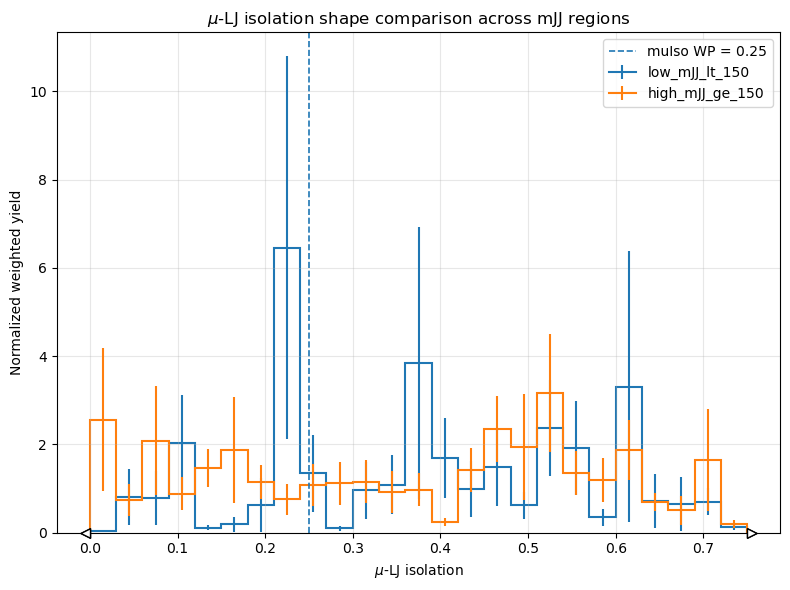

In [42]:
plot_normalized_iso_hists_by_mjj_region(
    mjj_regions_no_inclusive,
    variable="mu_iso",
    xlabel=r"$\mu$-LJ isolation",
    outname="normalized_muIso_hists_by_mjj_region",
)

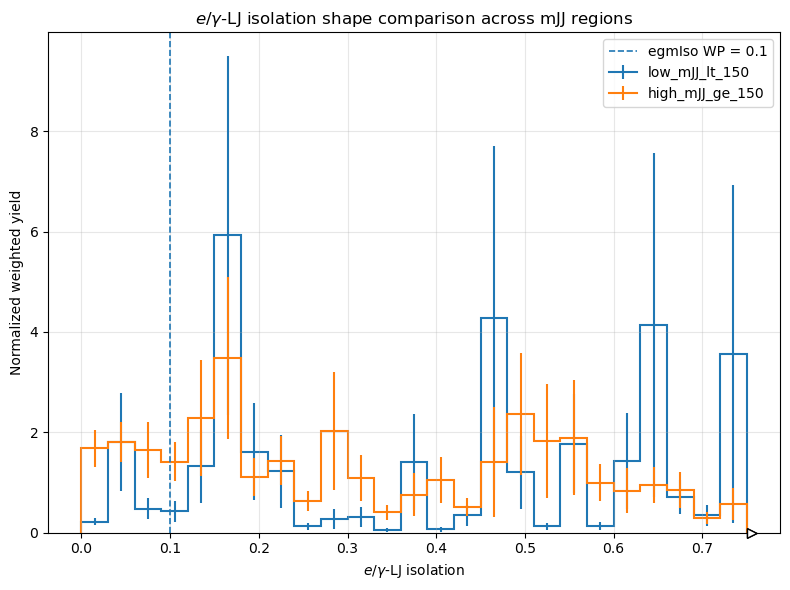

In [38]:
plot_normalized_iso_hists_by_mjj_region(
    mjj_regions_no_inclusive,
    variable="egm_iso",
    xlabel=r"$e/\gamma$-LJ isolation",
    outname="normalized_egmIso_hists_by_mjj_region",
)

In [43]:
def plot_egm_hist_with_without_mu_cut(
    df,
    region_name,
    mu_cut=MU_WP,
    outname=None,
    bins=N_BINS_1D,
    low=ISO_MIN,
    high=ISO_MAX,
):
    egm = df["egm_iso"].to_numpy(dtype=float)
    mu = df["mu_iso"].to_numpy(dtype=float)
    w = df["weight"].to_numpy(dtype=float)

    base_mask = np.isfinite(egm) & np.isfinite(mu) & np.isfinite(w)
    mu_pass_mask = base_mask & (mu <= mu_cut)

    h_all = make_weighted_hist(
        values=egm[base_mask],
        weights=w[base_mask],
        bins=bins,
        low=low,
        high=high,
        name="egm_iso",
        label=r"$e/\gamma$-LJ isolation",
    )

    h_mu_pass = make_weighted_hist(
        values=egm[mu_pass_mask],
        weights=w[mu_pass_mask],
        bins=bins,
        low=low,
        high=high,
        name="egm_iso",
        label=r"$e/\gamma$-LJ isolation",
    )

    h_all_norm = normalize_hist(h_all)
    h_mu_pass_norm = normalize_hist(h_mu_pass)

    centers, widths, ratio, ratio_unc = hist_ratio(h_mu_pass_norm, h_all_norm)

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(8, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
    )

    ax = axes[0]

    hep.histplot(
        h_all_norm,
        ax=ax,
        yerr=True,
        histtype="step",
        label="No muIso cut",
    )

    hep.histplot(
        h_mu_pass_norm,
        ax=ax,
        yerr=True,
        histtype="step",
        label=rf"With $\mu$ iso $\leq {mu_cut}$",
    )

    ax.axvline(
        EGM_WP,
        linestyle="--",
        linewidth=1.2,
        label=f"egmIso WP = {EGM_WP}",
    )

    ax.set_ylabel("Normalized weighted yield")
    ax.set_title(
        rf"$e/\gamma$-LJ isolation with/without $\mu$-iso cut: {region_name}"
    )
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]

    mask = np.isfinite(ratio) & np.isfinite(ratio_unc)

    ax.axhline(1.0, linestyle="--", linewidth=1.0)

    ax.errorbar(
        centers[mask],
        ratio[mask],
        yerr=ratio_unc[mask],
        xerr=widths[mask],
        fmt="o",
        capsize=2,
    )

    ax.set_xlabel(r"$e/\gamma$-LJ isolation")
    ax.set_ylabel("Ratio")
    ax.set_ylim(0, 2)
    ax.grid(True, alpha=0.3)

    fig.tight_layout()

    if outname is None:
        outname = f"egmIso_hist_with_without_muIsoCut_{region_name}"

    fig.savefig(OUTDIR / f"{outname}.png", dpi=300)
    fig.savefig(OUTDIR / f"{outname}.pdf")
    plt.show()

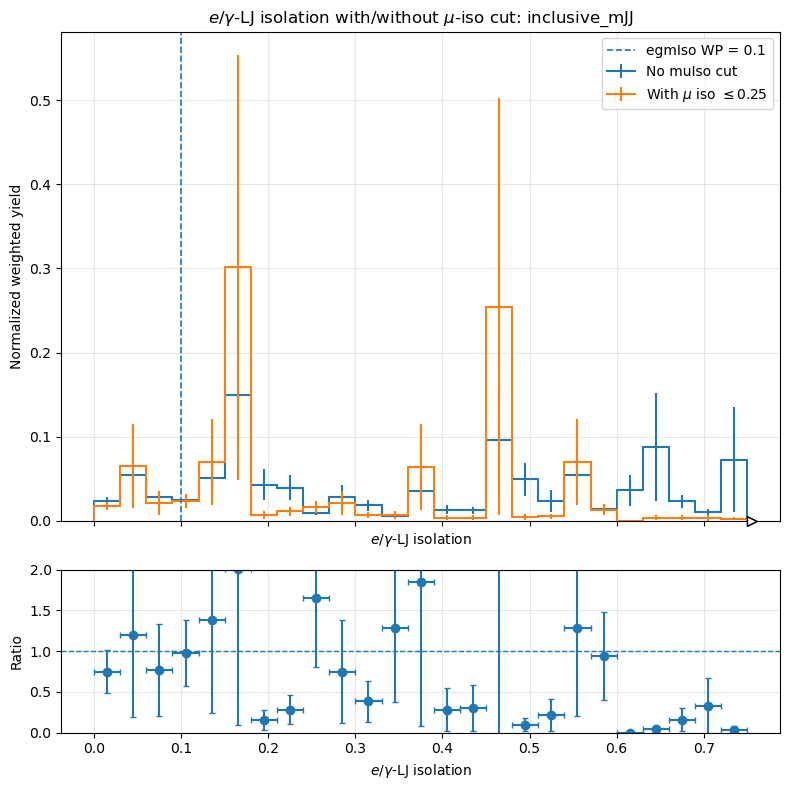

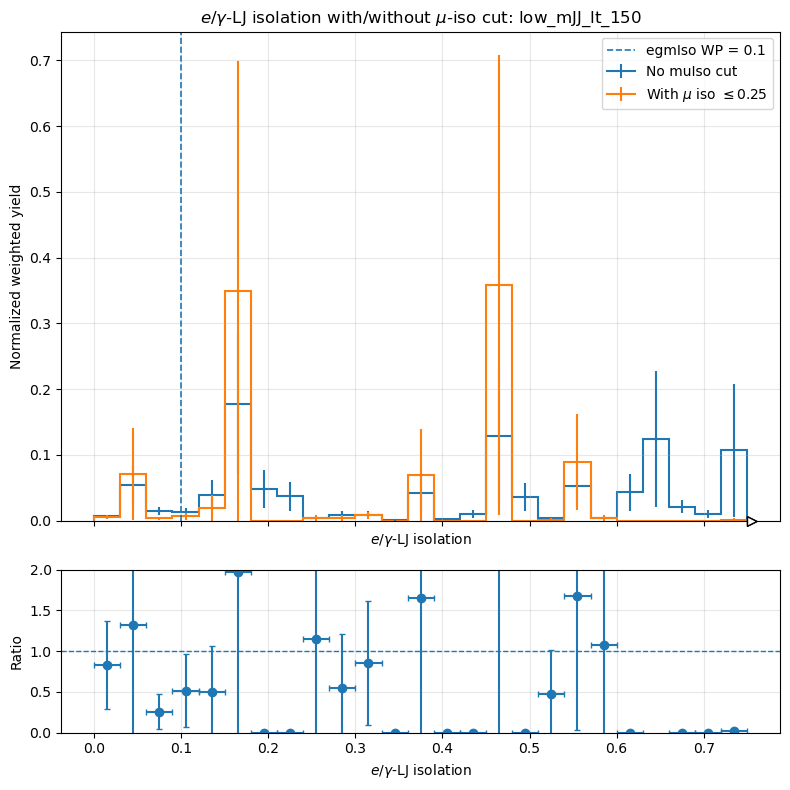

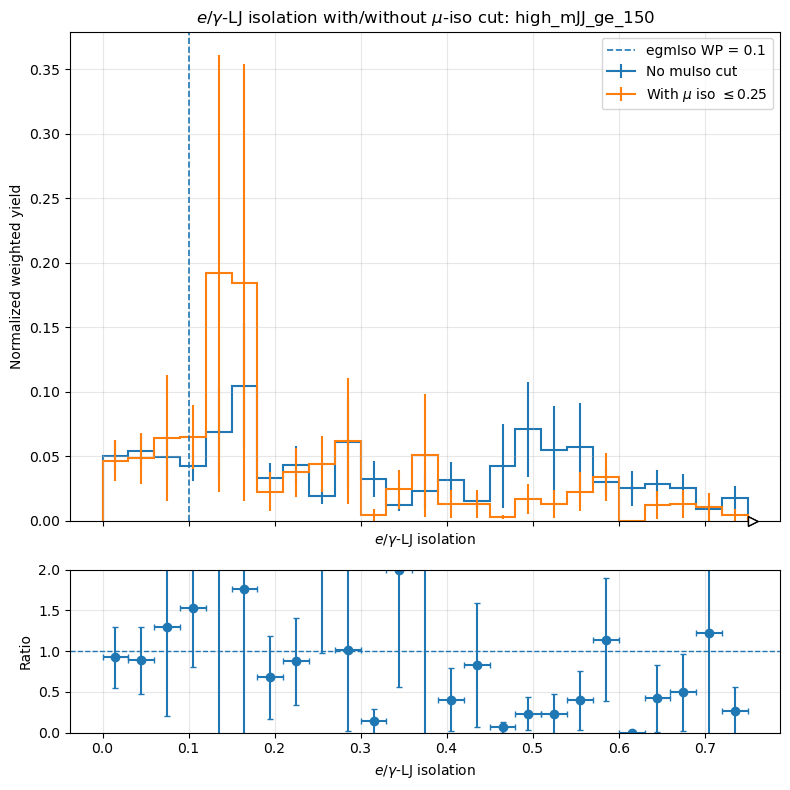

In [44]:
for region_name, df in mjj_regions.items():
    plot_egm_hist_with_without_mu_cut(
        df,
        region_name=region_name,
        mu_cut=MU_WP,
        outname=f"egmIso_hist_with_without_muIsoCut_{region_name}",
    )

In [46]:
def plot_mu_hist_with_without_egm_cut(
    df,
    region_name,
    egm_cut=EGM_WP,
    outname=None,
    bins=N_BINS_1D,
    low=ISO_MIN,
    high=ISO_MAX,
):
    mu = df["mu_iso"].to_numpy(dtype=float)
    egm = df["egm_iso"].to_numpy(dtype=float)
    w = df["weight"].to_numpy(dtype=float)

    base_mask = np.isfinite(mu) & np.isfinite(egm) & np.isfinite(w)
    egm_pass_mask = base_mask & (egm <= egm_cut)

    h_all = make_weighted_hist(
        values=mu[base_mask],
        weights=w[base_mask],
        bins=bins,
        low=low,
        high=high,
        name="mu_iso",
        label=r"$\mu$-LJ isolation",
    )

    h_egm_pass = make_weighted_hist(
        values=mu[egm_pass_mask],
        weights=w[egm_pass_mask],
        bins=bins,
        low=low,
        high=high,
        name="mu_iso",
        label=r"$\mu$-LJ isolation",
    )

    h_all_norm = normalize_hist(h_all)
    h_egm_pass_norm = normalize_hist(h_egm_pass)

    centers, widths, ratio, ratio_unc = hist_ratio(h_egm_pass_norm, h_all_norm)

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(8, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
    )

    ax = axes[0]

    hep.histplot(
        h_all_norm,
        ax=ax,
        yerr=True,
        histtype="step",
        label="No egmIso cut",
    )

    hep.histplot(
        h_egm_pass_norm,
        ax=ax,
        yerr=True,
        histtype="step",
        label=rf"With $e/\gamma$ iso $\leq {egm_cut}$",
    )

    ax.axvline(
        MU_WP,
        linestyle="--",
        linewidth=1.2,
        label=f"muIso WP = {MU_WP}",
    )

    ax.set_ylabel("Normalized weighted yield")
    ax.set_title(
        rf"$\mu$-LJ isolation with/without $e/\gamma$-iso cut: {region_name}"
    )
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]

    mask = np.isfinite(ratio) & np.isfinite(ratio_unc)

    ax.axhline(1.0, linestyle="--", linewidth=1.0)

    ax.errorbar(
        centers[mask],
        ratio[mask],
        yerr=ratio_unc[mask],
        xerr=widths[mask],
        fmt="o",
        capsize=2,
    )

    ax.set_xlabel(r"$\mu$-LJ isolation")
    ax.set_ylabel("Ratio")
    ax.set_ylim(0, 2)
    ax.grid(True, alpha=0.3)

    fig.tight_layout()

    if outname is None:
        outname = f"muIso_hist_with_without_egmIsoCut_{region_name}"

    fig.savefig(OUTDIR / f"{outname}.png", dpi=300)
    fig.savefig(OUTDIR / f"{outname}.pdf")
    plt.show()

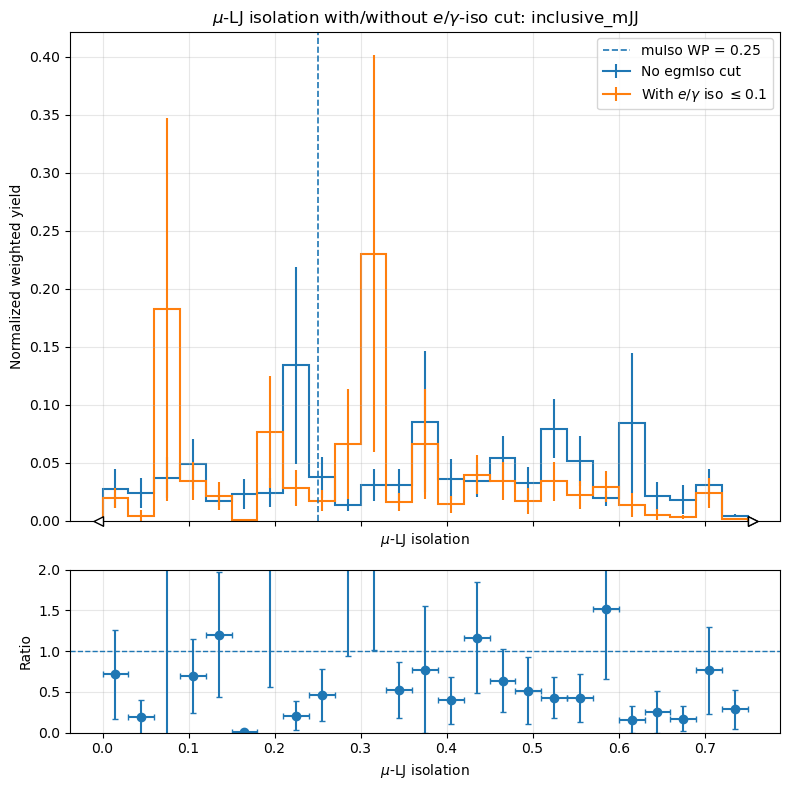

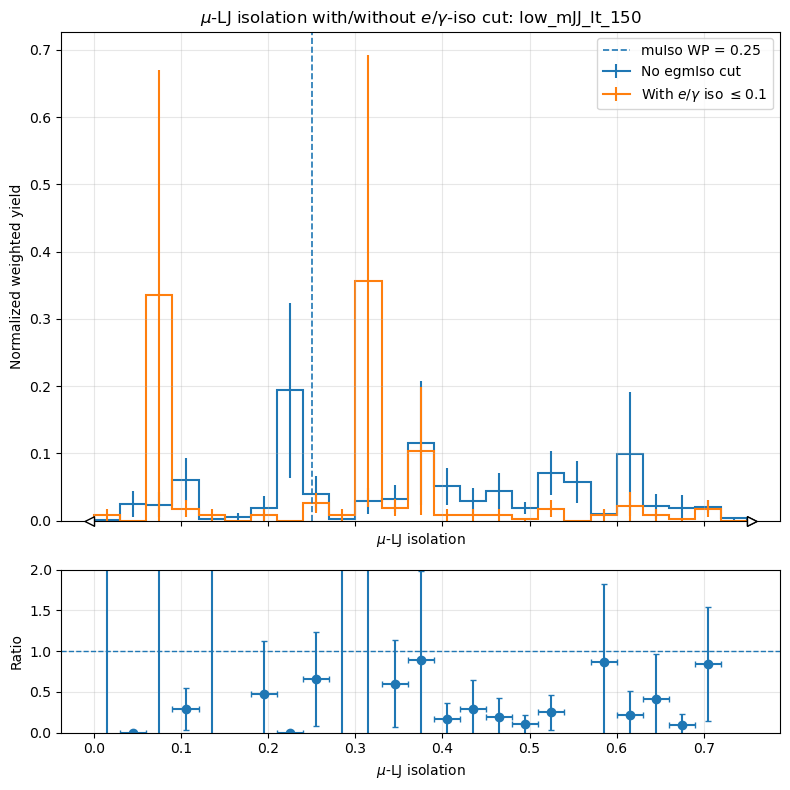

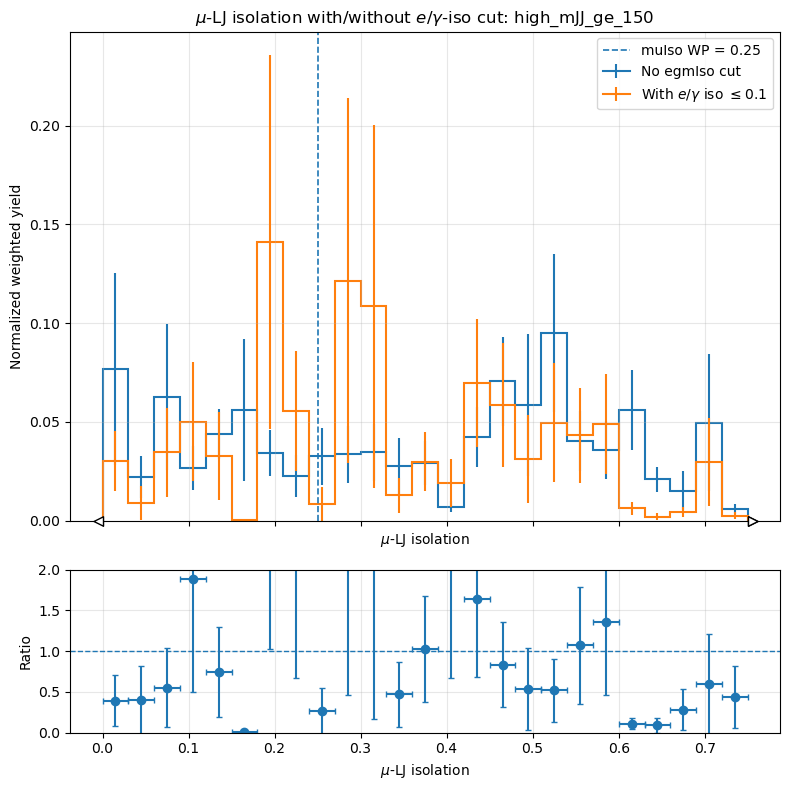

In [47]:
for region_name, df in mjj_regions.items():
    plot_mu_hist_with_without_egm_cut(
        df,
        region_name=region_name,
        egm_cut=EGM_WP,
        outname=f"muIso_hist_with_without_egmIsoCut_{region_name}",
    )

In [48]:
def plot_2d_iso_density(df, region_name, outname, bins=None):
    if bins is None:
        bins = np.linspace(ISO_MIN, ISO_MAX, N_BINS_2D + 1)

    x = df["mu_iso"].to_numpy(dtype=float)
    y = df["egm_iso"].to_numpy(dtype=float)
    w = df["weight"].to_numpy(dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)

    h, xedges, yedges = np.histogram2d(
        x[mask],
        y[mask],
        bins=[bins, bins],
        weights=w[mask],
    )

    fig, ax = plt.subplots(figsize=(8, 7))

    mesh = ax.pcolormesh(xedges, yedges, h.T, shading="auto")
    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label("Weighted background yield")

    ax.axvline(MU_WP, linestyle="--", linewidth=1.2, label=f"muIso WP = {MU_WP}")
    ax.axhline(EGM_WP, linestyle="--", linewidth=1.2, label=f"egmIso WP = {EGM_WP}")
    ax.scatter([MU_WP], [EGM_WP], marker="*", s=180, edgecolor="black", zorder=5)

    ax.set_xlabel(r"$\mu$-LJ isolation")
    ax.set_ylabel(r"$e/\gamma$-LJ isolation")
    ax.set_title(f"Iso-iso background density: {region_name}")
    ax.legend()

    fig.tight_layout()
    fig.savefig(OUTDIR / f"{outname}.png", dpi=300)
    fig.savefig(OUTDIR / f"{outname}.pdf")
    plt.show()

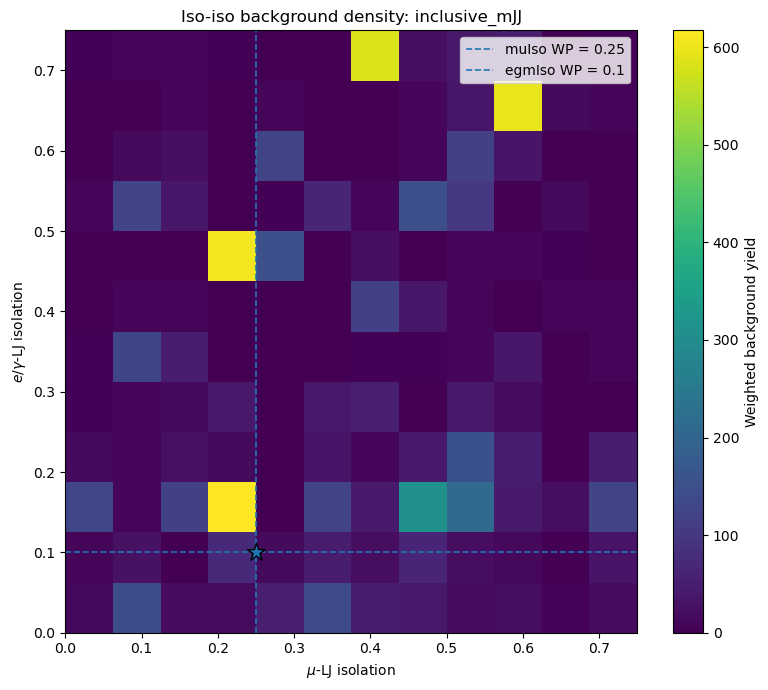

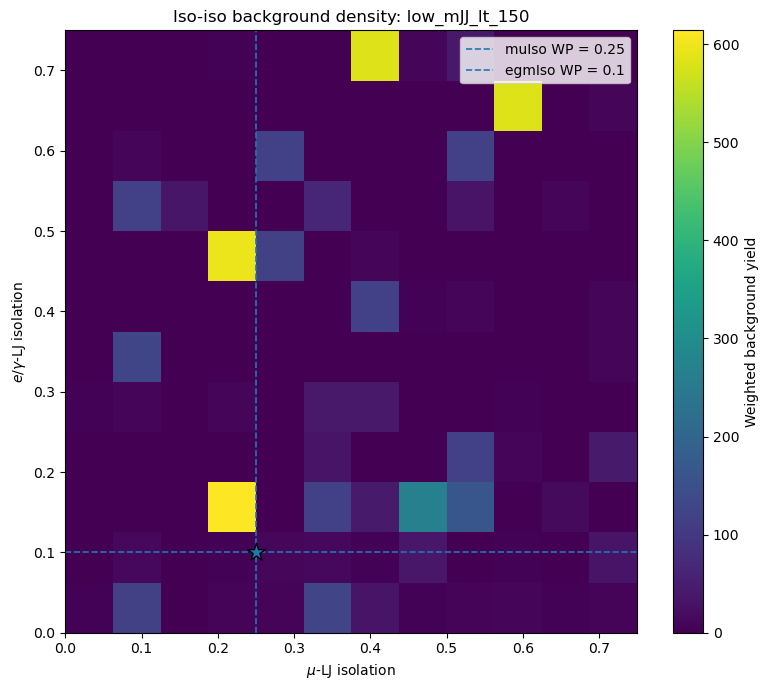

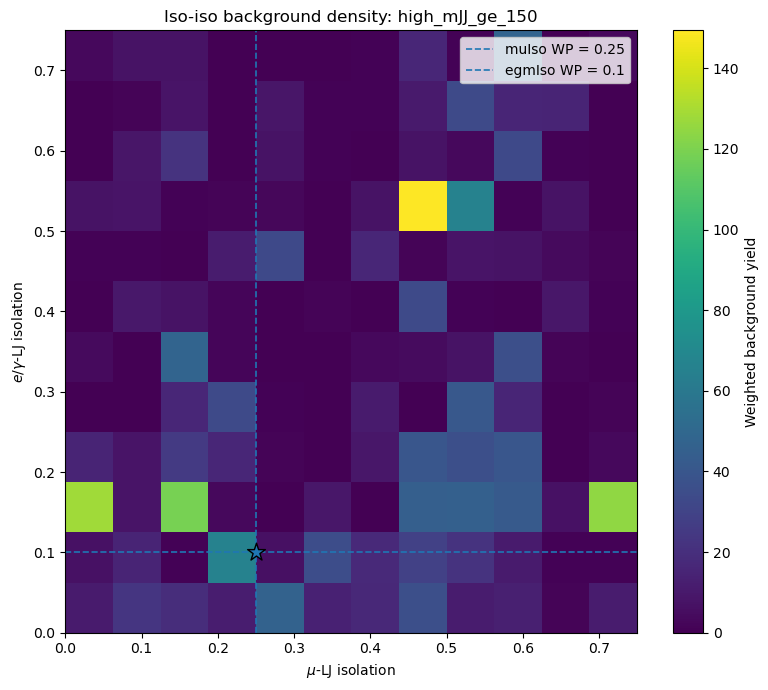

In [49]:
for region_name, df in mjj_regions.items():
    plot_2d_iso_density(
        df,
        region_name=region_name,
        outname=f"isoiso_2d_density_{region_name}",
    )

In [50]:
def run_1d_isoiso_scan_from_df(
    df,
    scan_variable,
    scan_values,
    fixed_mu_iso=MU_WP,
    fixed_egm_iso=EGM_WP,
):
    rows = []

    for cut in scan_values:
        if scan_variable == "mu":
            mu_cut = float(cut)
            egm_cut = float(fixed_egm_iso)
        elif scan_variable == "egm":
            mu_cut = float(fixed_mu_iso)
            egm_cut = float(cut)
        else:
            raise ValueError("scan_variable must be 'mu' or 'egm'")

        metrics = compute_isoiso_abcd_from_df(
            df,
            mu_cut=mu_cut,
            egm_cut=egm_cut,
        )

        row = {
            "scan_variable": scan_variable,
            "scan_cut": float(cut),
            "muIsoCut": mu_cut,
            "egmIsoCut": egm_cut,
        }

        row.update(metrics)
        rows.append(row)

    return pd.DataFrame(rows)

In [51]:
scan_values = np.linspace(ISO_MIN, ISO_MAX, 76)

scan_outputs = {}

for region_name, df in mjj_regions.items():
    mu_scan = run_1d_isoiso_scan_from_df(
        df,
        scan_variable="mu",
        scan_values=scan_values,
        fixed_mu_iso=MU_WP,
        fixed_egm_iso=EGM_WP,
    )

    egm_scan = run_1d_isoiso_scan_from_df(
        df,
        scan_variable="egm",
        scan_values=scan_values,
        fixed_mu_iso=MU_WP,
        fixed_egm_iso=EGM_WP,
    )

    scan_outputs[(region_name, "mu")] = mu_scan
    scan_outputs[(region_name, "egm")] = egm_scan

    mu_scan.to_csv(OUTDIR / f"muIso_scan_fixed_egmIso_{region_name}.csv", index=False)
    egm_scan.to_csv(OUTDIR / f"egmIso_scan_fixed_muIso_{region_name}.csv", index=False)

print("Done running 1D scans.")

Done running 1D scans.


In [52]:
def plot_three_panel_background_scan(
    df,
    scan_variable,
    selected_cut,
    fixed_cut,
    region_name,
    outname,
    closure_ylim=(0, 3),
    tf_ylim=(0, 5),
    log_counts=False,
):
    df = df.copy().sort_values("scan_cut")
    x = df["scan_cut"].to_numpy(dtype=float)

    if scan_variable == "mu":
        xlabel = r"$\mu$-LJ isolation cut"
        fixed_label = rf"fixed $e/\gamma$-LJ iso = {fixed_cut:.3f}"
        selected_label = rf"selected $\mu$ iso = {selected_cut:.3f}"
    elif scan_variable == "egm":
        xlabel = r"$e/\gamma$-LJ isolation cut"
        fixed_label = rf"fixed $\mu$-LJ iso = {fixed_cut:.3f}"
        selected_label = rf"selected $e/\gamma$ iso = {selected_cut:.3f}"
    else:
        raise ValueError("scan_variable must be 'mu' or 'egm'")

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(10, 12),
        sharex=True,
        gridspec_kw={"height_ratios": [1.2, 1.0, 1.2]},
    )

    # Top: closure
    ax = axes[0]

    closure = df["closure"].to_numpy(dtype=float)
    closure_unc = df["closureUnc"].to_numpy(dtype=float)

    mask = np.isfinite(x) & np.isfinite(closure) & np.isfinite(closure_unc)

    ax.errorbar(
        x[mask],
        closure[mask],
        yerr=closure_unc[mask],
        marker="o",
        linestyle="-",
        capsize=2,
        label=r"Closure ($A_{\mathrm{pred}}/A_{\mathrm{obs}}$)",
    )

    ax.axhline(1.0, linestyle="--", linewidth=1.2, label="Perfect closure")
    ax.axhline(1.1, linestyle=":", linewidth=1.2, label=r"$\pm 10\%$")
    ax.axhline(0.9, linestyle=":", linewidth=1.2)
    ax.axvline(selected_cut, linestyle="--", linewidth=1.2, label=selected_label)

    ax.set_ylabel(r"Closure: $A_{\mathrm{pred}}/A_{\mathrm{obs}}$")
    ax.set_ylim(*closure_ylim)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Middle: transfer factors
    ax = axes[1]

    tf_ac = df["tf_AC"].to_numpy(dtype=float)
    tf_ac_unc = df["tf_AC_unc"].to_numpy(dtype=float)
    tf_bd = df["tf_BD"].to_numpy(dtype=float)
    tf_bd_unc = df["tf_BD_unc"].to_numpy(dtype=float)

    mask_ac = np.isfinite(x) & np.isfinite(tf_ac) & np.isfinite(tf_ac_unc)
    mask_bd = np.isfinite(x) & np.isfinite(tf_bd) & np.isfinite(tf_bd_unc)

    ax.errorbar(
        x[mask_ac],
        tf_ac[mask_ac],
        yerr=tf_ac_unc[mask_ac],
        marker="o",
        linestyle="-",
        capsize=2,
        label="A/C",
    )

    ax.errorbar(
        x[mask_bd],
        tf_bd[mask_bd],
        yerr=tf_bd_unc[mask_bd],
        marker="s",
        linestyle="-",
        capsize=2,
        label="B/D",
    )

    ax.axvline(selected_cut, linestyle="--", linewidth=1.2)
    ax.set_ylabel("Transfer factor")
    ax.set_ylim(*tf_ylim)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Bottom: counts
    ax = axes[2]

    for region, marker in zip(["A", "B", "C", "D"], ["o", "s", "^", "D"]):
        y = df[f"{region}Counts"].to_numpy(dtype=float)
        yerr = df[f"{region}_Unc"].to_numpy(dtype=float)

        mask_region = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr)

        ax.errorbar(
            x[mask_region],
            y[mask_region],
            yerr=yerr[mask_region],
            marker=marker,
            linestyle="-",
            capsize=2,
            label=region,
        )

    ax.axvline(selected_cut, linestyle="--", linewidth=1.2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Background yield")

    if log_counts:
        ax.set_yscale("log")

    ax.legend(ncol=4)
    ax.grid(True, alpha=0.3)

    title = (
        f"Iso-Iso ABCD 1D scan: {region_name}\n"
        f"{fixed_label}, "
        rf"$d\phi \geq {DPHI_CUT}$, "
        f"pixelCut={PIXEL_CUT}"
    )

    fig.suptitle(title, fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    fig.savefig(OUTDIR / f"{outname}.png", dpi=300)
    fig.savefig(OUTDIR / f"{outname}.pdf")
    plt.show()

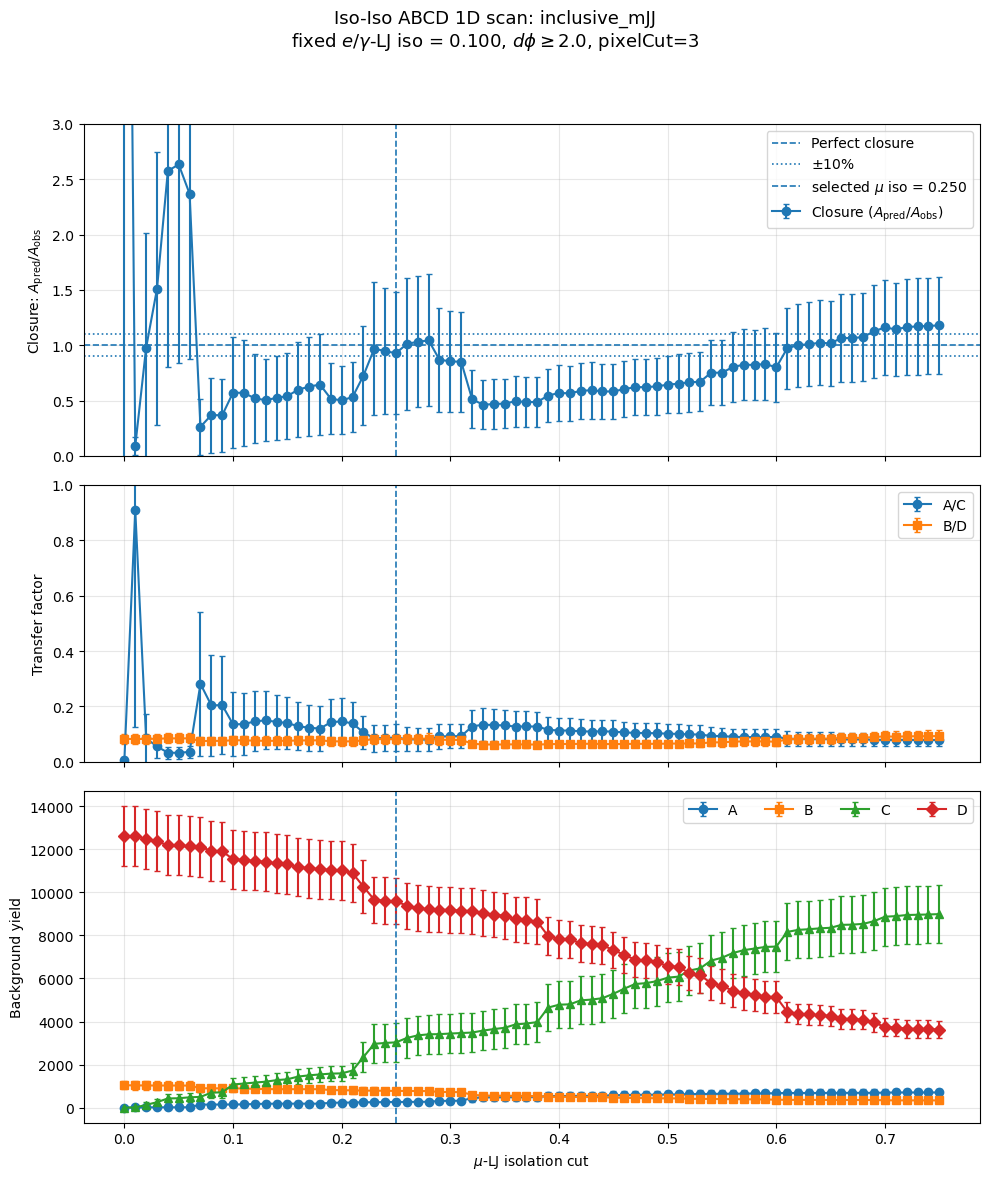

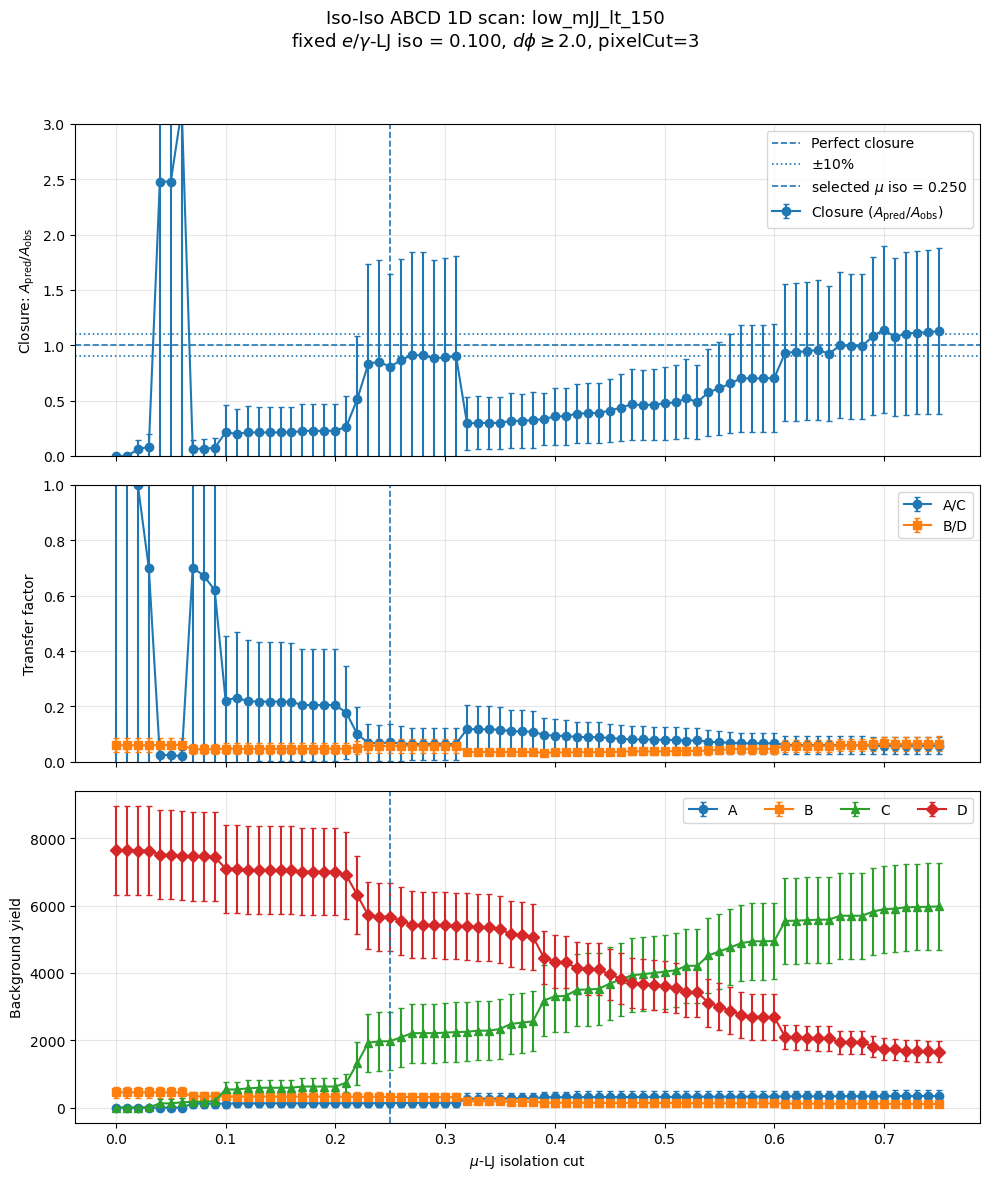

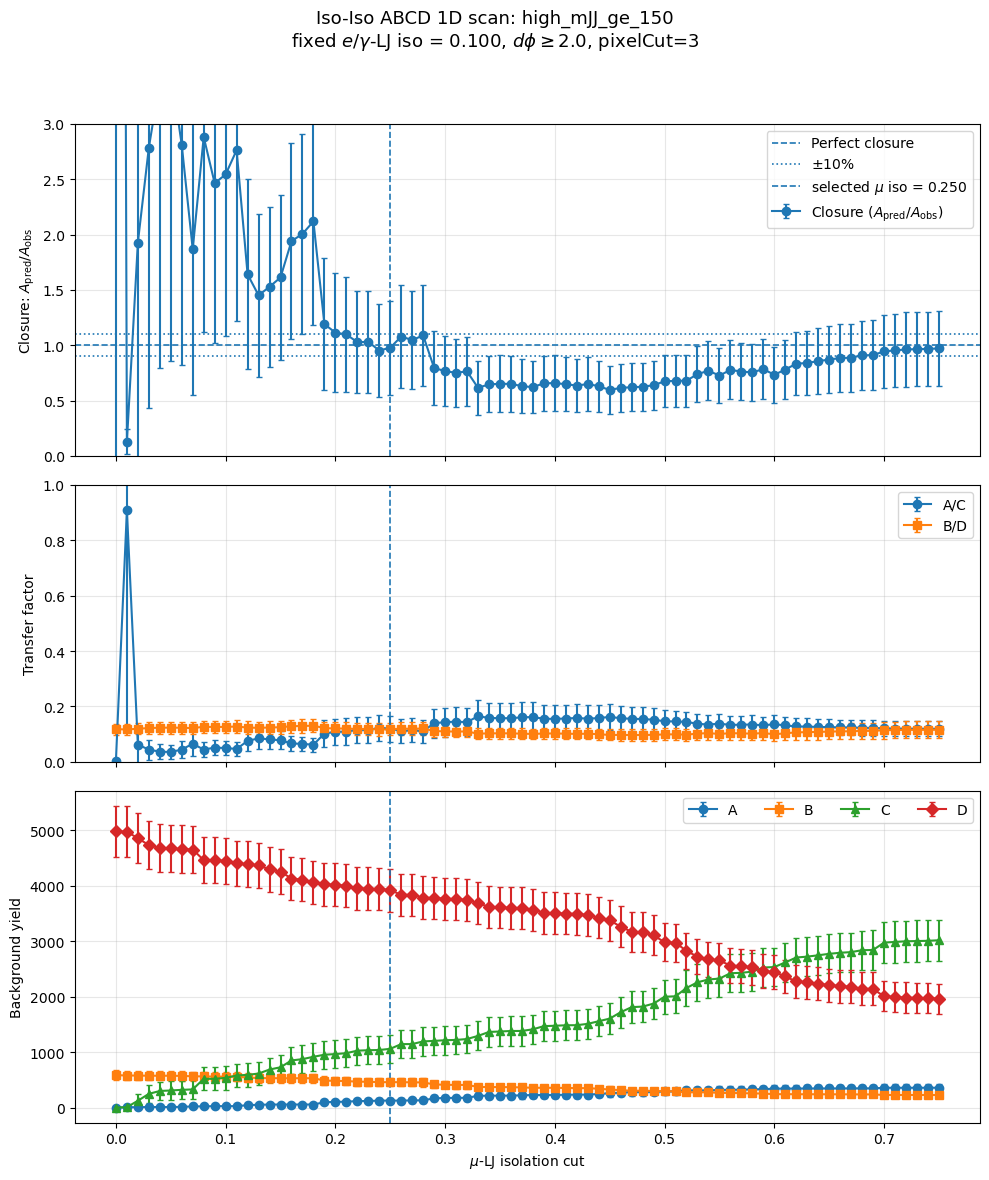

In [55]:
for region_name in mjj_regions.keys():
    plot_three_panel_background_scan(
        scan_outputs[(region_name, "mu")],
        scan_variable="mu",
        selected_cut=MU_WP,
        fixed_cut=EGM_WP,
        region_name=region_name,
        outname=f"three_panel_muIso_scan_{region_name}",
        closure_ylim=(0, 3),
        tf_ylim=(0, 1),
        log_counts=False,
    )

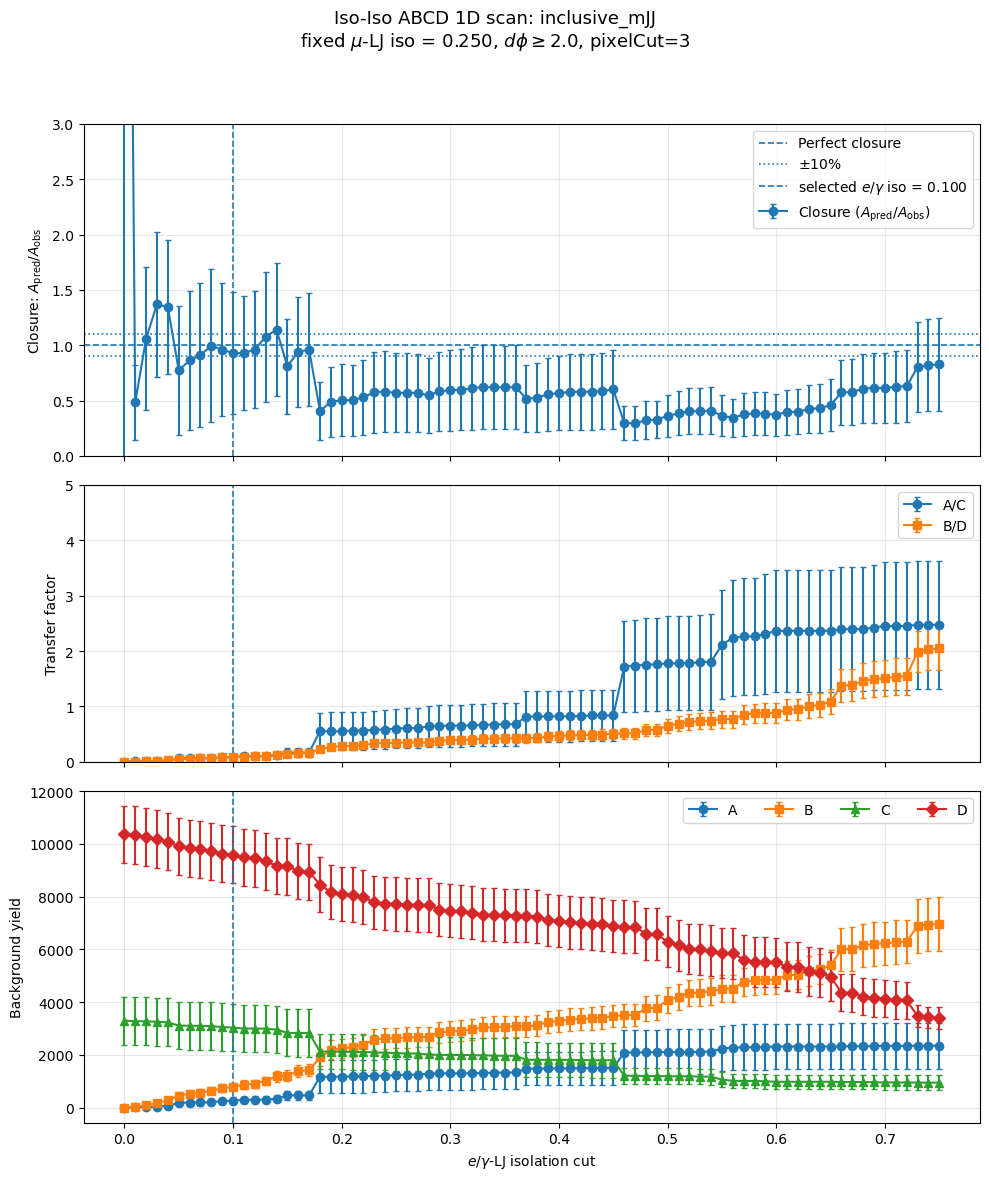

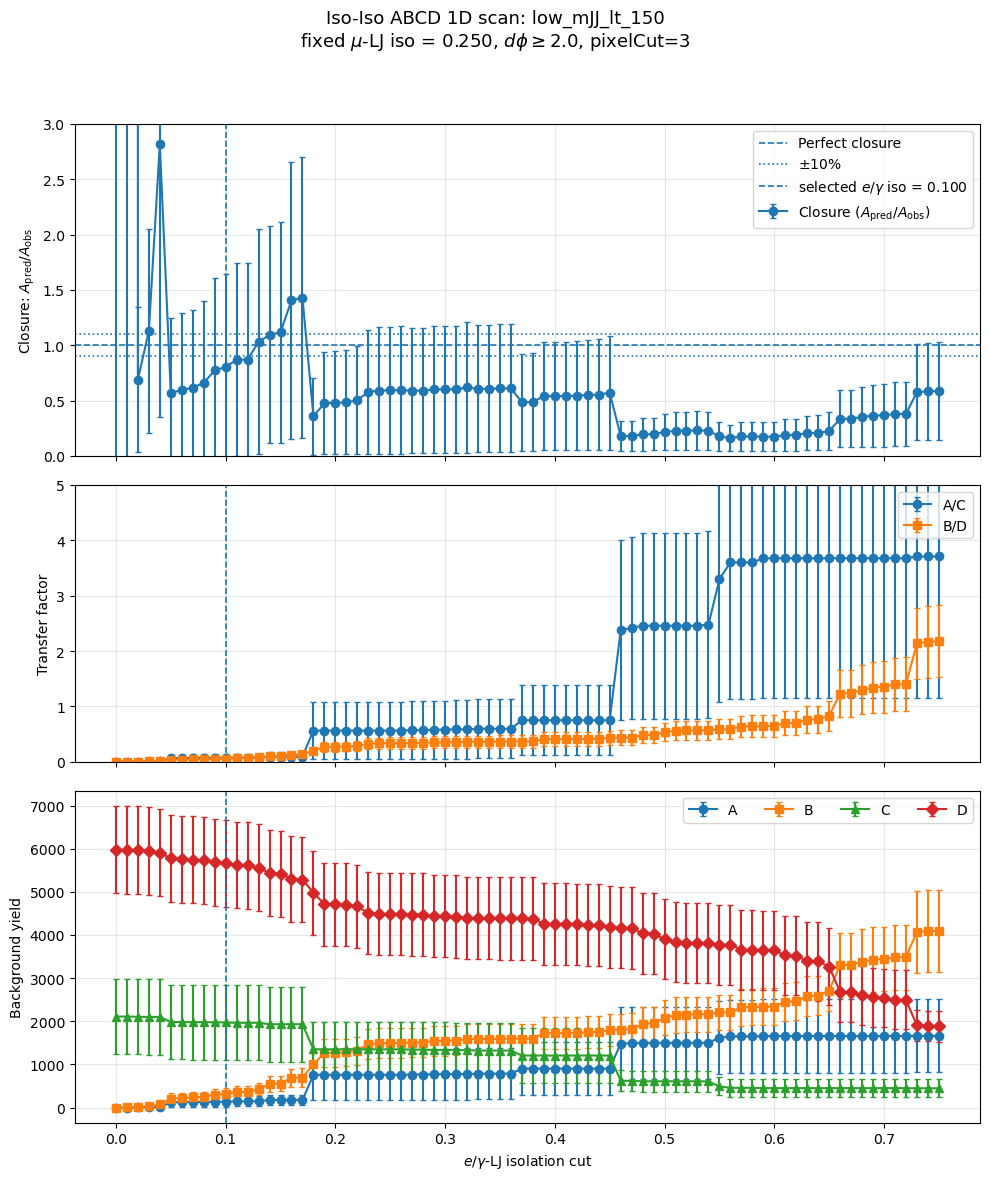

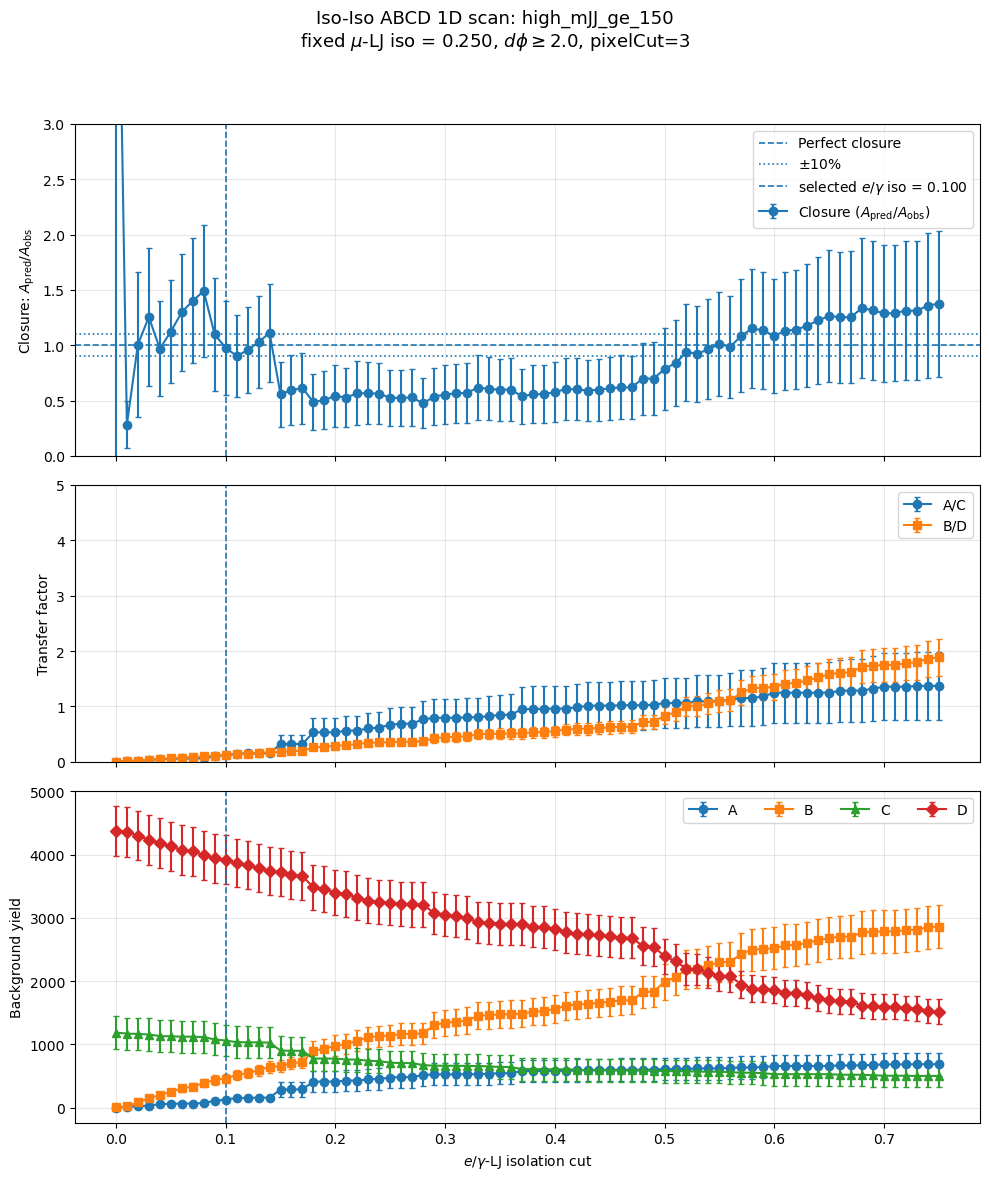

In [56]:
for region_name in mjj_regions.keys():
    plot_three_panel_background_scan(
        scan_outputs[(region_name, "egm")],
        scan_variable="egm",
        selected_cut=EGM_WP,
        fixed_cut=MU_WP,
        region_name=region_name,
        outname=f"three_panel_egmIso_scan_{region_name}",
        closure_ylim=(0, 3),
        tf_ylim=(0, 5),
        log_counts=False,
    )

In [57]:
def build_background_event_table_for_mjj_sculpting(backgrounds):
    """
    Build a flat background table before applying dPhi, mJJ, or pixel/displacement cuts.

    This is useful for checking whether the mJJ split sculpts:
      - dPhi
      - pixelHits
      - muIso
      - egmIso

    We still require the variables to be finite where needed for plotting.
    """

    rows = []

    for i, sample in enumerate(backgrounds):
        required = [
            "isolation",
            "egm_isolation",
            "mJJ",
            "dPhi",
            "pixelHits",
            "pfMu_n",
            "dsaMu_n",
            "passing_weights",
            "xsec",
            "nevents",
        ]

        missing = [key for key in required if key not in sample]

        if missing:
            print(f"[warn] background sample {i} missing keys: {missing}")
            continue

        mu_iso = np.asarray(sample["isolation"], dtype=float)
        egm_iso = np.asarray(sample["egm_isolation"], dtype=float)
        mjj = np.asarray(sample["mJJ"], dtype=float)
        dphi = np.asarray(sample["dPhi"], dtype=float)

        pfmu_n = np.asarray(sample["pfMu_n"], dtype=float)
        dsamu_n = np.asarray(sample["dsaMu_n"], dtype=float)

        pixel_hits = np.asarray(sample["pixelHits"], dtype=object)
        pixel_hits = np.where(pixel_hits == None, np.nan, pixel_hits).astype(float)

        weights = np.asarray(sample["passing_weights"], dtype=float)
        scale = get_scale(sample)
        event_weight = scale * weights

        # Do NOT apply dPhi cut, mJJ cut, or pixel cut here.
        base_mask = (
            np.isfinite(mu_iso)
            & np.isfinite(egm_iso)
            & np.isfinite(mjj)
            & np.isfinite(dphi)
            & np.isfinite(event_weight)
        )

        sample_name = sample.get("sample_name", f"background_{i}")

        temp = pd.DataFrame(
            {
                "sample_index": i,
                "sample_name": sample_name,
                "mu_iso": mu_iso[base_mask],
                "egm_iso": egm_iso[base_mask],
                "mJJ": mjj[base_mask],
                "dPhi": dphi[base_mask],
                "pixelHits": pixel_hits[base_mask],
                "pfMu_n": pfmu_n[base_mask],
                "dsaMu_n": dsamu_n[base_mask],
                "weight": event_weight[base_mask],
            }
        )

        temp["has_pfMuon"] = temp["pfMu_n"] >= 1
        temp["has_dsaMuon"] = temp["dsaMu_n"] >= 1
        temp["pixelPass"] = temp["pixelHits"] <= PIXEL_CUT

        rows.append(temp)

    if not rows:
        raise RuntimeError("No background rows were built.")

    return pd.concat(rows, ignore_index=True)

In [58]:
bkg_sculpt_df = build_background_event_table_for_mjj_sculpting(backgrounds)

print(f"Rows before dPhi/pixel/mJJ cuts: {len(bkg_sculpt_df)}")
print(f"Weighted yield: {bkg_sculpt_df['weight'].sum():.3f}")

bkg_sculpt_df.head()

Rows before dPhi/pixel/mJJ cuts: 29850
Weighted yield: 71064.465


,sample_index,sample_name,mu_iso,egm_iso,mJJ,dPhi,pixelHits,pfMu_n,dsaMu_n,weight,has_pfMuon,has_dsaMuon,pixelPass
0,0,background_0,0.009015,0.178302,370.050862,2.671401,4.0,2.0,0.0,2.027297e-08,True,False,False
1,0,background_0,0.071296,0.016807,258.486239,2.025500,4.0,2.0,0.0,2.027297e-08,True,False,False
2,0,background_0,0.031711,0.123747,199.349426,3.033699,4.0,2.0,0.0,2.027297e-08,True,False,False
3,0,background_0,0.065971,2.455210,114.819981,2.494977,5.0,2.0,0.0,2.027297e-08,True,False,False
4,0,background_0,0.035472,0.083083,119.174962,2.545139,3.0,1.0,1.0,2.027297e-08,True,True,True


In [59]:
mjj_sculpt_regions = {
    "low_mJJ_lt_150": bkg_sculpt_df[bkg_sculpt_df["mJJ"] < MJJ_CUT].copy(),
    "high_mJJ_ge_150": bkg_sculpt_df[bkg_sculpt_df["mJJ"] >= MJJ_CUT].copy(),
}

for name, df in mjj_sculpt_regions.items():
    print(name)
    print(f"  rows = {len(df)}")
    print(f"  weighted yield = {df['weight'].sum():.3f}")

low_mJJ_lt_150
  rows = 11651
  weighted yield = 46620.576
high_mJJ_ge_150
  rows = 18199
  weighted yield = 24443.889


In [60]:
def plot_normalized_hist_low_vs_high_mjj(
    regions,
    variable,
    xlabel,
    outname,
    bins,
    low,
    high,
    cut_value=None,
    cut_label=None,
    require_mask_func=None,
):
    """
    Plot normalized weighted histograms for low/high mJJ regions.

    Parameters
    ----------
    require_mask_func:
        Optional function taking df and returning a boolean mask.
        Useful for pixelHits, where you may only want pfMuon events.
    """

    fig, ax = plt.subplots(figsize=(8, 6))

    for region_name, df in regions.items():
        if require_mask_func is not None:
            mask = require_mask_func(df)
            plot_df = df[mask].copy()
        else:
            plot_df = df.copy()

        h = make_weighted_hist(
            values=plot_df[variable],
            weights=plot_df["weight"],
            bins=bins,
            low=low,
            high=high,
            name=variable,
            label=xlabel,
        )

        h_norm = normalize_hist(h)

        hep.histplot(
            h_norm,
            ax=ax,
            yerr=True,
            histtype="step",
            label=region_name,
        )

    if cut_value is not None:
        ax.axvline(
            cut_value,
            linestyle="--",
            linewidth=1.3,
            label=cut_label if cut_label is not None else f"cut = {cut_value}",
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Normalized weighted yield")
    ax.set_title(f"{xlabel}: low vs high mJJ")
    ax.legend()
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(OUTDIR / f"{outname}.png", dpi=300)
    fig.savefig(OUTDIR / f"{outname}.pdf")
    plt.show()

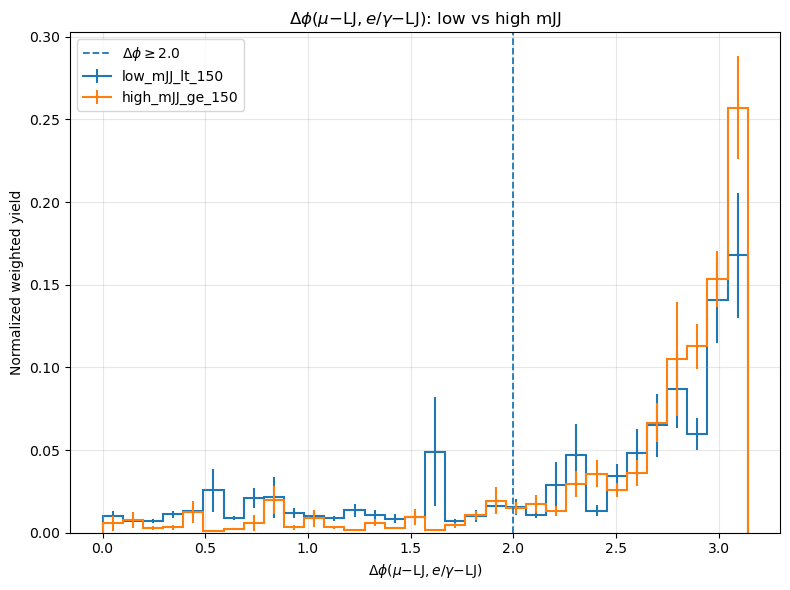

In [61]:
plot_normalized_hist_low_vs_high_mjj(
    regions=mjj_sculpt_regions,
    variable="dPhi",
    xlabel=r"$\Delta\phi(\mu\mathrm{-LJ}, e/\gamma\mathrm{-LJ})$",
    outname="dPhi_shape_low_vs_high_mJJ_before_dPhiCut",
    bins=32,
    low=0.0,
    high=np.pi,
    cut_value=DPHI_CUT,
    cut_label=rf"$\Delta\phi \geq {DPHI_CUT}$",
)

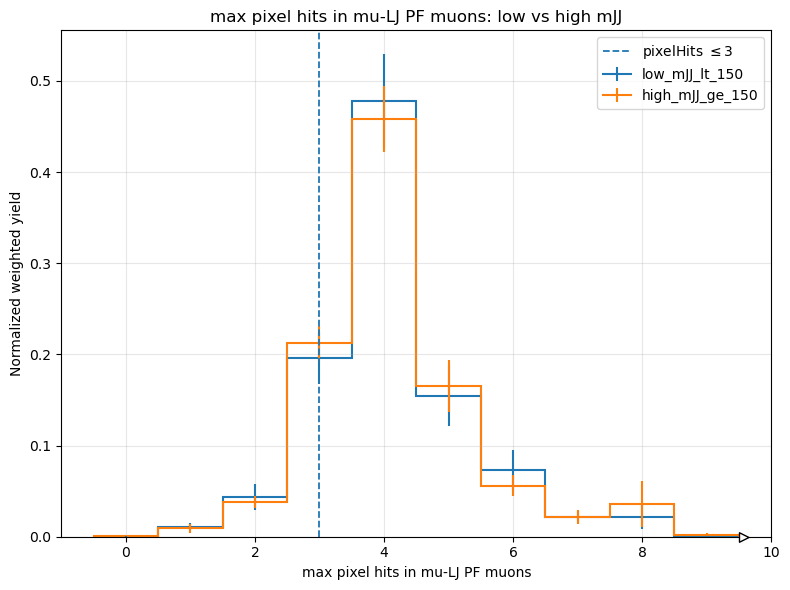

In [62]:
plot_normalized_hist_low_vs_high_mjj(
    regions=mjj_sculpt_regions,
    variable="pixelHits",
    xlabel="max pixel hits in mu-LJ PF muons",
    outname="pixelHits_shape_low_vs_high_mJJ_pfMuonEvents",
    bins=10,
    low=-0.5,
    high=9.5,
    cut_value=PIXEL_CUT,
    cut_label=rf"pixelHits $\leq {PIXEL_CUT}$",
    require_mask_func=lambda df: (df["has_pfMuon"]) & np.isfinite(df["pixelHits"]),
)

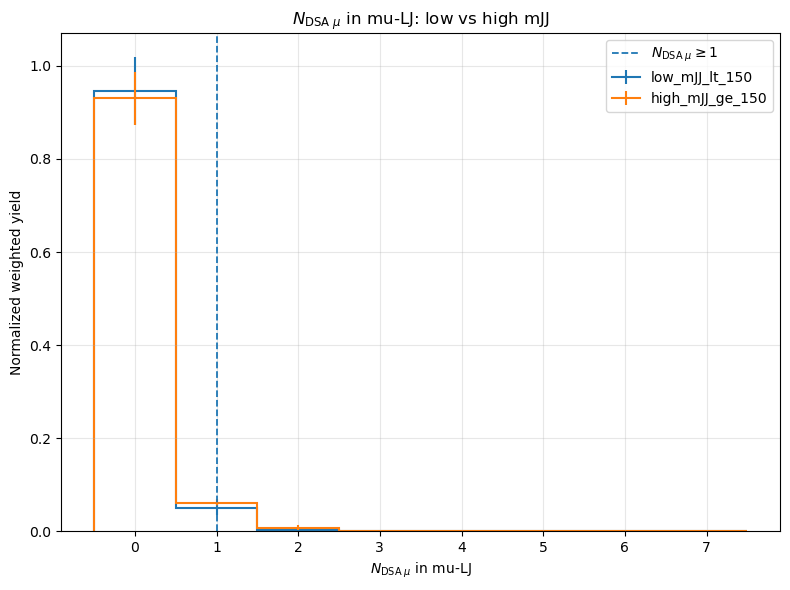

In [63]:
plot_normalized_hist_low_vs_high_mjj(
    regions=mjj_sculpt_regions,
    variable="dsaMu_n",
    xlabel=r"$N_{\mathrm{DSA}\ \mu}$ in mu-LJ",
    outname="dsaMu_n_shape_low_vs_high_mJJ",
    bins=8,
    low=-0.5,
    high=7.5,
    cut_value=1,
    cut_label=r"$N_{\mathrm{DSA}\ \mu} \geq 1$",
)

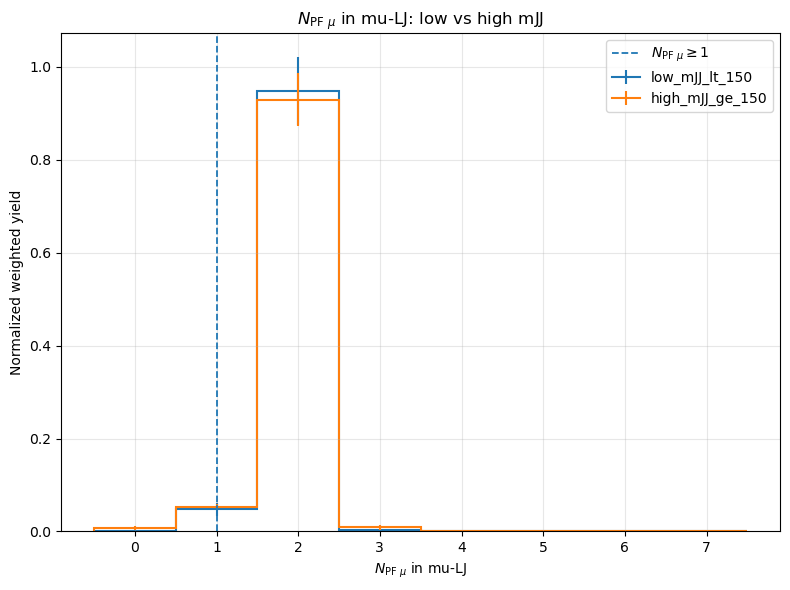

In [64]:
plot_normalized_hist_low_vs_high_mjj(
    regions=mjj_sculpt_regions,
    variable="pfMu_n",
    xlabel=r"$N_{\mathrm{PF}\ \mu}$ in mu-LJ",
    outname="pfMu_n_shape_low_vs_high_mJJ",
    bins=8,
    low=-0.5,
    high=7.5,
    cut_value=1,
    cut_label=r"$N_{\mathrm{PF}\ \mu} \geq 1$",
)

In [65]:
def plot_2d_mjj_vs_variable(
    df,
    variable,
    xlabel,
    outname,
    xbins,
    xlow,
    xhigh,
    ybins=30,
    ylow=0,
    yhigh=500,
    x_cut=None,
    y_cut=MJJ_CUT,
):
    x = df[variable].to_numpy(dtype=float)
    y = df["mJJ"].to_numpy(dtype=float)
    w = df["weight"].to_numpy(dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(w)

    h, xedges, yedges = np.histogram2d(
        x[mask],
        y[mask],
        bins=[
            np.linspace(xlow, xhigh, xbins + 1),
            np.linspace(ylow, yhigh, ybins + 1),
        ],
        weights=w[mask],
    )

    fig, ax = plt.subplots(figsize=(8, 7))

    mesh = ax.pcolormesh(xedges, yedges, h.T, shading="auto")
    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label("Weighted background yield")

    if x_cut is not None:
        ax.axvline(x_cut, linestyle="--", linewidth=1.2, label=f"{xlabel} cut")

    if y_cut is not None:
        ax.axhline(y_cut, linestyle="--", linewidth=1.2, label=rf"$m_{{JJ}} = {y_cut}$")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$m_{JJ}$")
    ax.set_title(rf"$m_{{JJ}}$ vs {xlabel}")
    ax.legend()

    fig.tight_layout()
    fig.savefig(OUTDIR / f"{outname}.png", dpi=300)
    fig.savefig(OUTDIR / f"{outname}.pdf")
    plt.show()

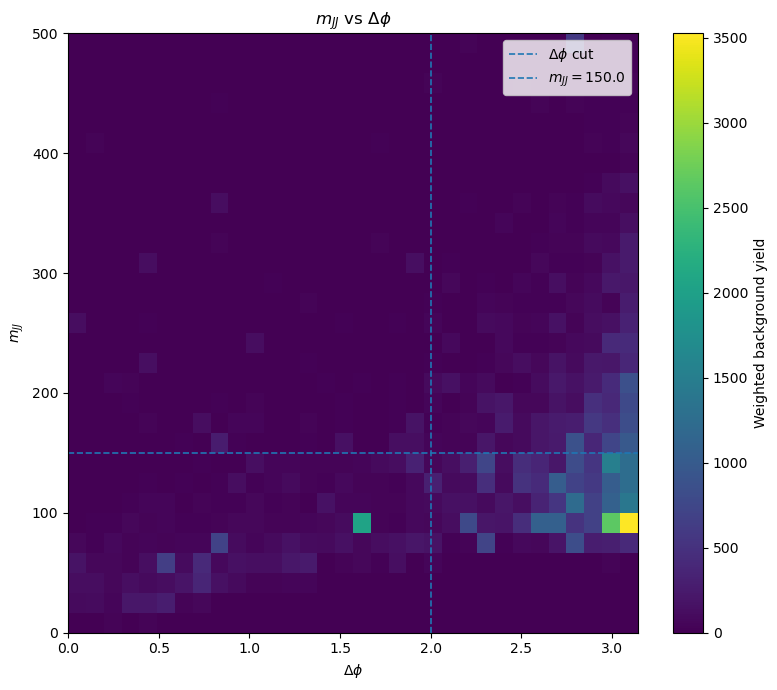

In [66]:
plot_2d_mjj_vs_variable(
    bkg_sculpt_df,
    variable="dPhi",
    xlabel=r"$\Delta\phi$",
    outname="mJJ_vs_dPhi",
    xbins=32,
    xlow=0,
    xhigh=np.pi,
    ybins=30,
    ylow=0,
    yhigh=500,
    x_cut=DPHI_CUT,
    y_cut=MJJ_CUT,
)

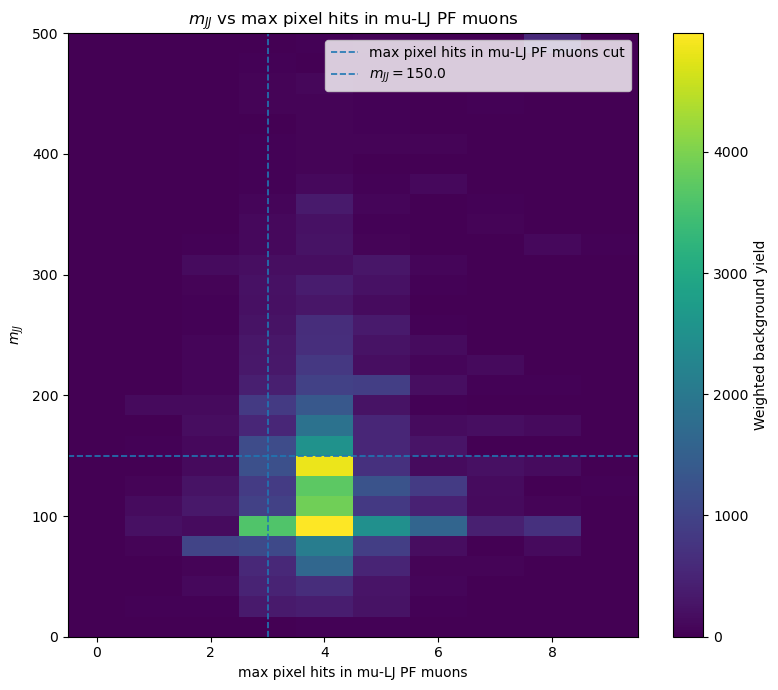

In [67]:
pf_df = bkg_sculpt_df[
    (bkg_sculpt_df["has_pfMuon"])
    & np.isfinite(bkg_sculpt_df["pixelHits"])
].copy()

plot_2d_mjj_vs_variable(
    pf_df,
    variable="pixelHits",
    xlabel="max pixel hits in mu-LJ PF muons",
    outname="mJJ_vs_pixelHits_pfMuonEvents",
    xbins=10,
    xlow=-0.5,
    xhigh=9.5,
    ybins=30,
    ylow=0,
    yhigh=500,
    x_cut=PIXEL_CUT,
    y_cut=MJJ_CUT,
)